# Error Analysis: Beverage Image Classification
# 誤分類分析：コンビニ飲料画像分類

This notebook analyzes the evaluation results of the beverage image classification model.

このNotebookでは、コンビニ飲料画像分類モデルの評価結果を分析します。

In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
if not (project_root / 'logs').exists():
    project_root = project_root.parent

logs_dir = project_root / 'logs'
cm = pd.read_csv(logs_dir / 'confusion_matrix.csv', index_col=0)
print('Confusion matrix shape:', cm.shape)
cm


Confusion matrix shape: (11, 11)


,pred_asakatsu_yasai,pred_bihidasu_yogurt,pred_dodekamin,pred_ichinichibun_no_yasai,pred_ocha_lemon_green,pred_oi_ocha_koi_cha,pred_oi_ocha_ryokucha,pred_savas_milk_protein_banana,pred_savas_whey_protein,pred_zero_cider_triple,pred_zero_cider_triple_plus_afa
true_asakatsu_yasai,15,0,0,0,0,0,0,0,0,0,0
true_bihidasu_yogurt,0,12,0,0,0,0,0,0,0,0,0
true_dodekamin,0,0,10,0,0,0,0,0,0,0,0
true_ichinichibun_no_yasai,0,0,0,15,0,0,0,0,0,0,0
true_ocha_lemon_green,0,0,0,0,14,0,0,0,0,0,0
true_oi_ocha_koi_cha,0,0,0,0,0,12,0,0,0,0,0
true_oi_ocha_ryokucha,0,0,0,0,0,0,16,0,0,0,0
true_savas_milk_protein_banana,0,0,0,0,0,0,0,16,0,0,0
true_savas_whey_protein,0,0,0,0,0,0,0,0,17,0,0
true_zero_cider_triple,0,0,0,0,0,0,0,0,0,10,0


In [6]:
print((logs_dir / 'test_metrics.txt').read_text(encoding='utf-8'))


Test accuracy: 0.9866

                            precision    recall  f1-score   support

            asakatsu_yasai     1.0000    1.0000    1.0000        15
           bihidasu_yogurt     1.0000    1.0000    1.0000        12
                 dodekamin     1.0000    1.0000    1.0000        10
     ichinichibun_no_yasai     1.0000    1.0000    1.0000        15
          ocha_lemon_green     1.0000    1.0000    1.0000        14
           oi_ocha_koi_cha     1.0000    1.0000    1.0000        12
          oi_ocha_ryokucha     1.0000    1.0000    1.0000        16
 savas_milk_protein_banana     1.0000    1.0000    1.0000        16
        savas_whey_protein     1.0000    1.0000    1.0000        17
         zero_cider_triple     0.8333    1.0000    0.9091        10
zero_cider_triple_plus_afa     1.0000    0.8333    0.9091        12

                  accuracy                         0.9866       149
                 macro avg     0.9848    0.9848    0.9835       149
              weighted 

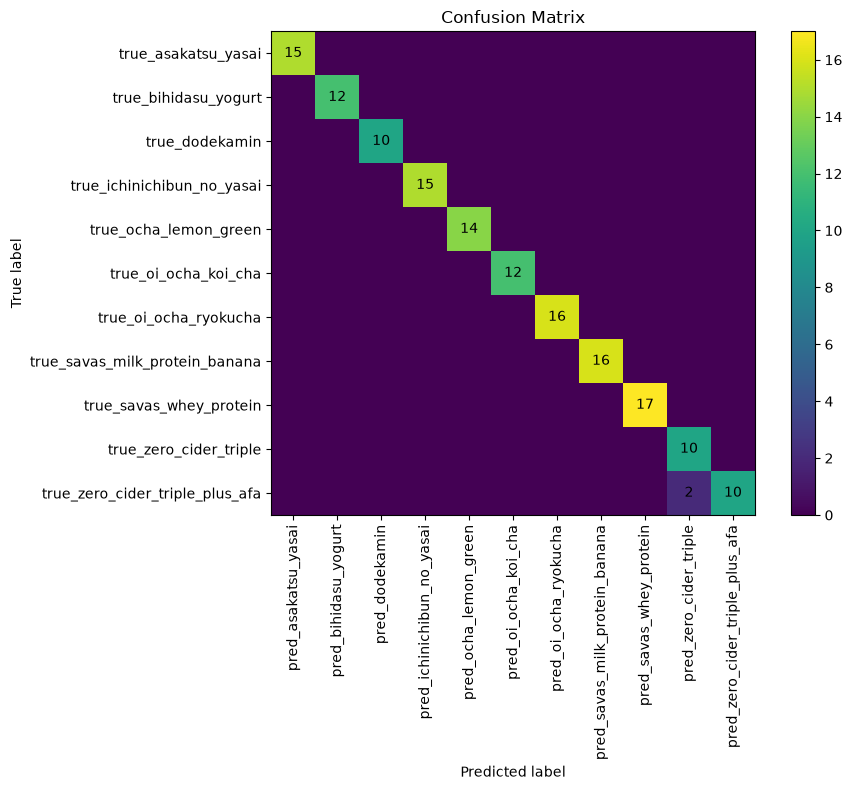

In [7]:
plt.figure(figsize=(10, 8))
plt.imshow(cm.values)
plt.colorbar()
plt.xticks(range(len(cm.columns)), cm.columns, rotation=90)
plt.yticks(range(len(cm.index)), cm.index)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm.iloc[i, j]
        if value != 0:
            plt.text(j, i, str(value), ha='center', va='center')

plt.tight_layout()
plt.show()


In [8]:
errors = cm.copy()
for label in errors.index:
    if label in errors.columns:
        errors.loc[label, label] = 0

error_pairs = (
    errors.stack()
    .reset_index()
    .rename(columns={'level_0': 'true_label', 'level_1': 'predicted_label', 0: 'count'})
)
error_pairs = error_pairs[error_pairs['count'] > 0]
error_pairs.sort_values('count', ascending=False)


,true_label,predicted_label,count
96,true_savas_whey_protein,pred_savas_whey_protein,17
72,true_oi_ocha_ryokucha,pred_oi_ocha_ryokucha,16
84,true_savas_milk_protein_banana,pred_savas_milk_protein_banana,16
0,true_asakatsu_yasai,pred_asakatsu_yasai,15
36,true_ichinichibun_no_yasai,pred_ichinichibun_no_yasai,15
48,true_ocha_lemon_green,pred_ocha_lemon_green,14
12,true_bihidasu_yogurt,pred_bihidasu_yogurt,12
60,true_oi_ocha_koi_cha,pred_oi_ocha_koi_cha,12
24,true_dodekamin,pred_dodekamin,10
108,true_zero_cider_triple,pred_zero_cider_triple,10


## Interpretation / 考察

The main errors are expected to occur between visually similar beverage packages, especially products with similar package color, layout, and text.

主な誤分類は、パッケージの色、レイアウト、文字配置が似ている飲料商品間で発生すると考えられます。